<a href="https://colab.research.google.com/github/FRA-0023/Causal-Networks/blob/main/notebooks/03_d_separation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
# Update package lists to ensure we install the latest versions.
!apt-get update
# Install necessary system libraries for graph visualization (graphviz) and Python development headers.
# 'python3-dev' is needed for building Python extensions, 'graphviz' and 'libgraphviz-dev' for PyGraphviz.
# 'pkg-config' helps locate compilation flags for libraries.
!apt install python3-dev graphviz libgraphviz-dev pkg-config
# Install Python libraries: 'networkx' for graph manipulation, 'pygraphviz' for advanced graph drawing,
# and 'matplotlib' for plotting.
!pip install networkx pygraphviz matplotlib

In [2]:
# Plots
# Import networkx for graph creation and manipulation (Graph, DiGraph for undirected/directed graphs).
import networkx as nx
from networkx import Graph, DiGraph
# Import graphviz_layout for drawing graphs using Graphviz algorithms, which often produce better layouts.
from networkx.drawing.nx_agraph import graphviz_layout
import pygraphviz # Although imported, often used implicitly by networkx.drawing.nx_agraph.
import matplotlib.pyplot as plt # For displaying plots.

import warnings
warnings.filterwarnings("ignore") # Ignore warnings, especially common ones from matplotlib/networkx.

# Data
# 'combinations' is used for generating pairs of parents in the moralization step.
from itertools import combinations
# 'typing' module for type hints to improve code readability and maintainability.
from typing import List, Set
import random # Imported but not used in the provided code, potentially for future extensions.

# An Implementation of the D-Separation Algorithm



By Alessio Zanga, Niccolò Rocchi and Fabio Stella

## Abstract

Let us give some essential definitions:

* We say that a path $p$ is **blocked** by a set of nodes $\mathbf{S}$ if at least one of these two conditions holds:

  1. $p$ contains a **chain** $A \rightarrow B \rightarrow C$ or a **fork** $A \leftarrow B \rightarrow C$ and $B \in \mathbf{S}$
  2. $p$ contains a collider $A \rightarrow B \leftarrow C$ such that the collision node $B \notin \mathbf{S}$ and also $De(B) \cap \mathbf{S} = \emptyset$.

* We say that two nodes $X$ and $Y$ are **d-separated** by $\mathbf{S}$ if every path between $X$ and $Y$ is blocked by $\mathbf{S}$.

* We say that two sets of nodes $\mathbf{X}$ and $\mathbf{Y}$ are **d-separated** by $\mathbf{S}$ if, for every couple of nodes $X_i \in \mathbf{X}$ and $Y_i \in \mathbf{Y}$, $X_i$ and $Y_i$ are d-separated by $\mathbf{S}$.

* The **Global Markov assumption** allows us to read d-separation statements among nodes as conditional independence statements:
$$
X \perp \!\! \perp_G Y | \mathbf{S} \implies X \perp \!\! \perp_P Y | \mathbf{S}
$$

  where the LHS speaks about graphical properties, while the RHS regards probability properties among random variables.

While the definition  d-separation is correct, it cannot be directly translated into a functional form. The aim of this notebook is to exploit a different version of d-separation for providing a possible implementation.

## Introduction

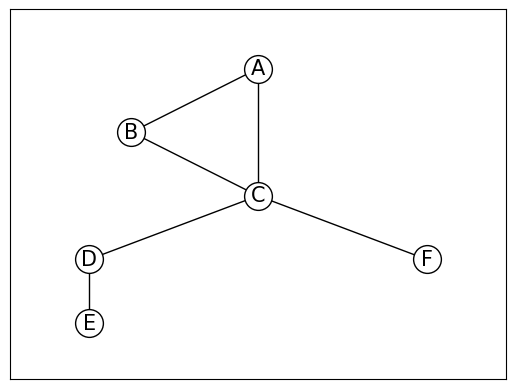

In [11]:
# Define an undirected graph for demonstrating u-separation.
H = Graph([("A", "B"), ("A", "C"), ("B", "C"), ("C", "D"), ("D", "E"), ("C", "F")])
# Draw the example undirected graph.
draw(H)

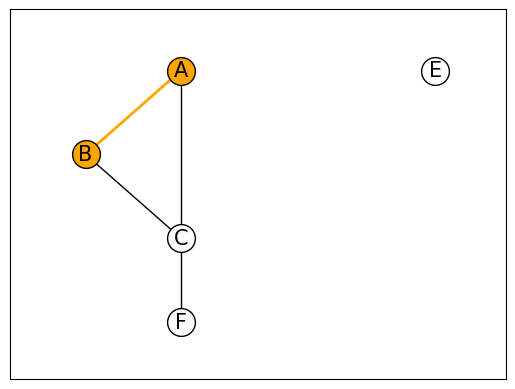

In [18]:
# Since the previous check indicated that {'A'} and {'B'} are NOT u-separated given {'D'},
# a path must exist between them. This code visually confirms that path.
# First, we identify the connected component that contains both 'A' and 'B'.
# Assuming Cs[0] is the relevant component as per previous output.
# Then, we find a simple path between 'A' and 'B' within that component's subgraph.
path = next(nx.all_simple_edge_paths(H_prime.subgraph(Cs[0]), "A", "B"))
# Draw the modified graph (H_prime) and highlight this path.
draw(H_prime, path)

An algorithmic definition of d-separation can be found in "Probabilistic Graphical Models: Principles and Techniques" by D. Koller and N. Friedman, page 136.

Let $\mathbf{X}$, $\mathbf{Y}$ and $\mathbf{Z}$ be three disjoint sets of $\mathbf{V}$ in the graph $G$. Let $\mathbf{S} = \mathbf{X} \cup \mathbf{Y} \cup \mathbf{Z}$ and $G^{[\mathbf{S}]}$ be the *upward closure* of $G$ over $\mathbf{S} \cup An(\mathbf{S})$. Let $H$ be the *moralized graph* of $G^{[\mathbf{S}]}$. Then *d-sep*$_G$($\mathbf{X}$, $\mathbf{Y}$, $\mathbf{Z}$) if and only if *u-sep*$_H$($\mathbf{X}, \mathbf{Y}, \mathbf{Z}$).

Let's split the definition step-by-step:



* Let $\mathbf{X}$, $\mathbf{Y}$ and $\mathbf{Z}$ be three disjoint sets of $\mathbf{V}$ in the graph $G$.
* Let $\mathbf{S} = \mathbf{X} \cup \mathbf{Y} \cup \mathbf{Z}$ and $G^{[\mathbf{S}]}$ be the *upward closure* of $G$ over $\mathbf{S} \cup An(\mathbf{S})$.
* Let $H$ be the *moralized graph* of $G^{[\mathbf{S}]}$.
* Then *d-sep*$_G$($\mathbf{X}, \mathbf{Y}, \mathbf{Z}$) if and only if *u-sep*$_H$($\mathbf{X}, \mathbf{Y}, \mathbf{Z}$).



Here it is an example of the whole process:

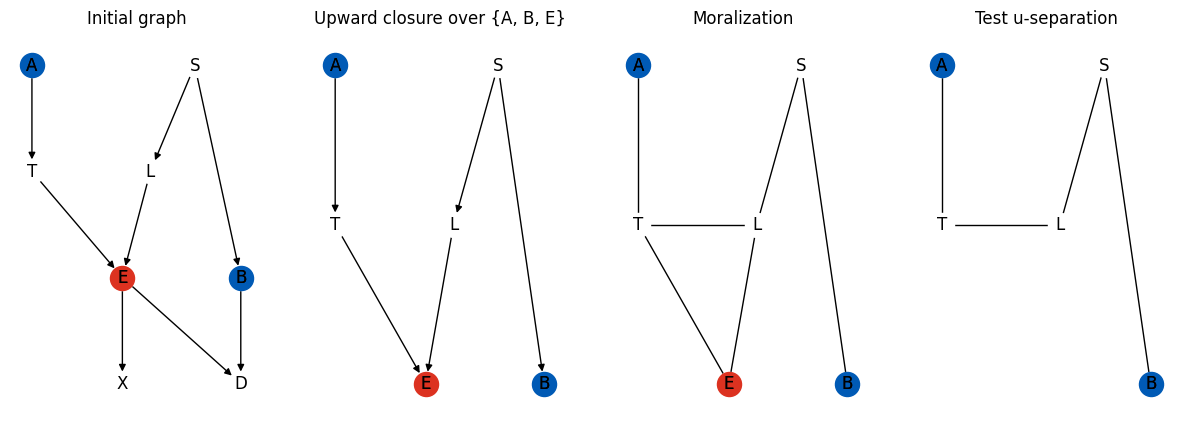

In [3]:
plt.figure(figsize = (15, 5)) # Create a figure to hold multiple subplots for comparison.

# Initial graph (Subplot 1)
plt.subplot(1, 4, 1) # Set up a 1x4 grid of plots, selecting the first position.
plt.gca().set_title("Initial graph") # Set title for the current subplot.
# Define the initial directed graph (G) with edges representing causal relationships.
G = DiGraph([("A", "T"), ("T", "E"), ("E", "X"), ("E", "D"), ("S", "L"), ("L", "E"), ("S", "B"), ("B", "D")])
nx.drawing.nx_agraph.write_dot(G,'G.dot') # Save graph in DOT format for Graphviz (not directly used for plotting here).
pos = graphviz_layout(G, prog='dot') # Compute layout using Graphviz 'dot' algorithm for directed graphs.
nx.draw(G, pos = pos, node_color="white", with_labels=True) # Draw all nodes and edges in white.
nx.draw(G.subgraph(["A", "B"]), pos = pos, node_color="#005AB5", with_labels=True) # Highlight nodes A and B.
nx.draw(G.subgraph(["E"]), pos = pos, node_color="#DC3220", with_labels=True) # Highlight node E.

# Upward closure (Subplot 2)
plt.subplot(1, 4, 2) # Select the second position in the grid.
plt.gca().set_title("Upward closure over {A, B, E}") # Set title for the current subplot.
# Create a new graph representing the upward closure, containing nodes A, B, E and their ancestors.
# This simplifies the graph for moralization by removing irrelevant nodes.
G = DiGraph([("A", "T"), ("T", "E"), ("S", "L"), ("L", "E"), ("S", "B")])
nx.drawing.nx_agraph.write_dot(G,'G.dot') # Save graph in DOT format.
nx.draw(G, pos = pos, node_color="white", with_labels=True) # Draw the upward closure graph.
nx.draw(G.subgraph(["A", "B"]), pos = pos, node_color="#005AB5", with_labels=True) # Highlight A and B.
nx.draw(G.subgraph(["E"]), pos = pos, node_color="#DC3220", with_labels=True) # Highlight E.

# Moralization (Subplot 3)
plt.subplot(1, 4, 3) # Select the third position in the grid.
plt.gca().set_title("Moralization") # Set title for the current subplot.
# Create an undirected graph representing the moralized version of the upward closure.
# Edges are added between previously unconnected parents sharing a common child (e.g., T and L both parent E).
G = Graph([("A", "T"), ("T", "E"), ("S", "L"), ("L", "E"), ("S", "B"), ("T", "L")])
nx.drawing.nx_agraph.write_dot(G,'G.dot') # Save graph in DOT format.
nx.draw(G, pos = pos, node_color="white", with_labels=True) # Draw the moralized graph.
nx.draw(G.subgraph(["A", "B"]), pos = pos, node_color="#005AB5", with_labels=True) # Highlight A and B.
nx.draw(G.subgraph(["E"]), pos = pos, node_color="#DC3220", with_labels=True) # Highlight E.

# u-separation (Subplot 4)
plt.subplot(1, 4, 4) # Select the fourth position in the grid.
plt.gca().set_title("Test u-separation") # Set title for the current subplot.
# Create an undirected graph from the moralized graph, removing conditioning nodes (E in this conceptual example).
# This graph is used to test for u-separation (undirected separation).
G = Graph([("A", "T"), ("S", "L"),  ("S", "B"), ("T", "L")])
nx.drawing.nx_agraph.write_dot(G,'G.dot') # Save graph in DOT format.
nx.draw(G, pos = pos, node_color="white", with_labels=True) # Draw the graph for u-separation testing.
nx.draw(G.subgraph(["A", "B"]), pos = pos, node_color="#005AB5", with_labels=True) # Highlight A and B for separation check.

## Implementation

 ### Plot style

Let's define a prettier plot style:

In [4]:
def draw(G, path: List[str] = []):
  """Draws a graph with optional highlighting for a given path."""
  plt.figure() # Create a new matplotlib figure for the graph.
  # Compute node positions using Graphviz 'dot' layout algorithm for better visualization.
  pos = graphviz_layout(G, prog = "dot")
  for v in G.nodes(): # Iterate through each node in the graph.
    node_color = "white" # Default color for nodes.
    # If the node is part of the specified path (either as a node itself or in an edge),
    # highlight it in orange.
    if any(v in e for e in path):
      node_color = "orange"
    # Draw the current node with specified style.
    nx.draw_networkx_nodes(
        G,
        pos = pos,
        nodelist = [v], # Draw only the current node.
        node_color = node_color,
        node_shape = "o", # Circle shape.
        node_size = 4e2, # Size of the node.
        edgecolors = "black", # Black border for nodes.
        margins = 0.2 # Margin around the nodes.
      )
  # Draw node labels on the graph.
  nx.draw_networkx_labels(G, pos = pos, font_size = 15)
  for e in G.edges(): # Iterate through each edge in the graph.
    width = 1.0 # Default edge width.
    edge_color = "black" # Default edge color.
    # If the edge is part of the specified path, highlight it with a thicker orange line.
    if e in path:
      width = 2
      edge_color = "orange"
    # Draw the current edge with specified style.
    nx.draw_networkx_edges(
        G,
        pos = pos,
        edgelist = [e], # Draw only the current edge.
        edge_color = edge_color,
        width = width,
        arrowsize = 15, # Size of the arrow for directed graphs.
    )

### A focus on [set operators](https://docs.python.org/3/library/stdtypes.html#set) in Python

In [5]:
# The boolean evaluation of an empty set is False. This is useful for checking if a set is empty.
print("Boolean({}): ", bool(set()))
# The boolean evaluation of a non-empty set is True. This indicates the presence of elements.
print("Boolean({'X', 'Y', 'Z'}): ", bool({"X", "Y", "Z"}))
# The union operator '|' combines elements from two sets without duplicates.
print(
  "{'X', 'Y'}  ∪  {'Y', 'Z'} == {'X', 'Y', 'Z'}: ",
   {"X", "Y"}  |  {"Y", "Z"} == {"X", "Y", "Z"}
)
# The intersection operator '&' returns elements common to both sets.
print(
  "{'X', 'Y'}  ∩  {'Y', 'Z'} == {'Y'}: ",
   {"X", "Y"}  &  {"Y", "Z"} == {"Y"}
)
# The difference operator '-' returns elements in the first set that are not in the second set.
print(
  "{'X', 'Y'}  \  {'Y', 'Z'} == {'X'}: ",
   {"X", "Y"}  -  {"Y", "Z"} == {"X"}
)
# The "subset or equal" operator '<=' checks if all elements of the first set are in the second set.
print(
  "{'X', 'Y'}  ⊆  {'Y', 'Z'}: ",
   {"X", "Y"}  <= {"Y", "Z"}
)

Boolean({}):  False
Boolean({'X', 'Y', 'Z'}):  True
{'X', 'Y'}  ∪  {'Y', 'Z'} == {'X', 'Y', 'Z'}:  True
{'X', 'Y'}  ∩  {'Y', 'Z'} == {'Y'}:  True
{'X', 'Y'}  \  {'Y', 'Z'} == {'X'}:  True
{'X', 'Y'}  ⊆  {'Y', 'Z'}:  False


### Implementing the Upward Closure of Directed Graphs


A collider $X \rightarrow Z \leftarrow Y$ is said to be an **immorality** (or **v-structure**) if there isn't any edge between $X$ and $Y$.

The moral graph of $G$ itself is not the right construct, because **there are paths in the undirected graph that correspond to colliders in $G$ that may or may not be blocked**.

For example, if our graph $G$ is $X \rightarrow Z \leftarrow Y$ and $Z$ is not observed, d-separation tells us that $X$ and $Y$ are independent, but the moralized graph for $G$ is the complete undirected graph, which does not have the same independence.

We first want to eliminate immoralities that are **not open** (i.e. blocked), so as to remove such cases.

To do so, we first construct a subgraph where we **remove all immoralities that do not have an observed descendant**. The elimination of such nodes does not change the independence properties of the distribution over the remaining variables, but does eliminate paths in the graph involving immoralities that are not open.

This process is called the **upward closure**, which consists in building the subgraph given a set of nodes and their ancestors.

In [6]:
def ancestors(G: DiGraph, S: Set[str]) -> Set[str]:
  """Compute the set of all ancestors in graph G for a given set of nodes S.

  Args:
    G: A directed graph (DiGraph) where relationships are defined.
    S: A set of nodes for which to find ancestors.

  Returns:
    A set containing all unique ancestors of the nodes in S, including the nodes in S themselves.
  """
  # For every node 's' in the input set 'S', we use networkx's nx.ancestors() function
  # to find all nodes from which 's' can be reached via a directed path.
  # We collect all unique ancestors into a single set 'An_S' using a set comprehension.
  # The union with S itself ensures that the nodes in S are also included in their 'ancestral set'.
  An_S = {an_s for s in S for an_s in nx.ancestors(G, s)} | S
  return An_S

In [7]:
def upward_closure(G: DiGraph, S: Set[str]) -> DiGraph:
  """Compute the upward closure (ancestral subgraph) of G for a given set of nodes S.

  The upward closure includes all nodes in S and all their ancestors, along with all
  edges from the original graph G that connect these selected nodes.
  This step is crucial for d-separation as it prunes the graph to only include
  nodes relevant to the observed variables and their causal history.

  Args:
    G: The original directed graph.
    S: The set of nodes for which to compute the upward closure.

  Returns:
    A new DiGraph representing the upward closure.
  """
  # Calculate the set of all nodes that are either in S or are an ancestor of a node in S.
  # This is the set of nodes that will form the upward closure.
  nodes_in_closure = S | ancestors(G, S)
  # Create a subgraph of G containing only these nodes and the edges between them.
  # This effectively 'prunes' the graph to only include paths relevant to S.
  return G.subgraph(nodes_in_closure)

### Implementing the Moral Graph of Directed Graphs

If directed graphs where equivalent to undirected graphs, then d-separation could be achieved by turning a directed graph into an undirected graph. Unfortunately, this is not the case. Or, at least, the **mapping** step is not that... direct.

A **moral graph** $H$ is an **undirected copy** of a directed graph $G$, where **each pair of parents** of each node in $G$ is connected by an undirected edge.

The difficult step here is not to implement the algorithm, but to **undestand why we need to connect the parents** of each node. We try now to catch the point, but if you want the full story, please, refer to [Markov Networks](https://en.wikipedia.org/wiki/Markov_random_field) and ask a Master Thesis to us.

For each immorality $X \rightarrow W \leftarrow Y$ in $G^{[\mathbf{S}]}$, we have that either $W$ belongs to the ancestors of $\mathbf{Z}$, or it belongs to the ancestors of $A$ (or $B$). In the first case, the immorality path is open and association flows between $X$ and $Y$. In the second case, it doesn't really matter if the association flows across the immorality, because it is enough that it flows between $A$ (or $B$) and $X$, $Y$.

However, in case of $W$ belongs to $\mathbf{Z}$, it will block any undirected path passing through it in the undirected graph $H$. So, we cannot just turn $G$ to be undirected. In order to preserve the associational behaviour we mentioned before, we connect any couple of parents, in case they are not already connected.

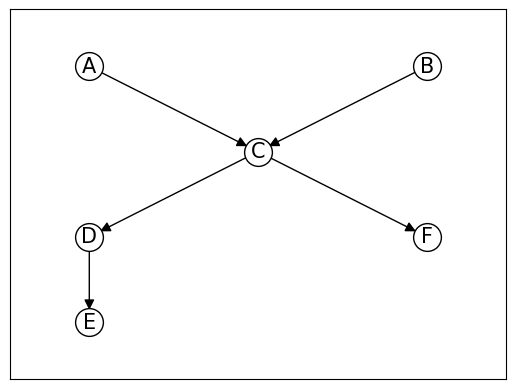

In [8]:
# Define a directed graph for demonstrating moralization.
G = DiGraph([("A", "C"), ("B", "C"), ("C", "D"), ("D", "E"), ("C", "F")])

# Draw the initial directed graph.
draw(G)

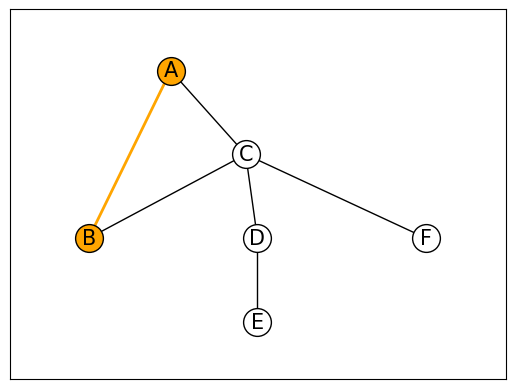

In [9]:
# Step 1: Build an undirected copy of the directed graph G.
# This converts all directed edges into undirected edges.
H = G.to_undirected()

# Step 2: Identify pairs of parents sharing a common child (colliders) in the original directed graph.
# These pairs need to be 'married' by adding an undirected edge between them in the moral graph.
E = set() # Initialize an empty set to store new edges to be added.
for v in G.nodes(): # Iterate through each node in the directed graph G.
  Pa_v = list(G.predecessors(v)) # Get a list of all direct parents of the current node v.
  # If a node has more than one parent, those parents are considered 'unmarried' siblings
  # with a common child (v).
  # Iterate through all unique pairs of these parents.
  for (u, w) in combinations(Pa_v, 2):
    # Add an undirected edge between these two parents (u, w) to the set E.
    # The exact order (u, w) or (w, u) doesn't matter for undirected edges, but 'combinations' handles this.
    E = E | {(u, w)}

# Step 3: Add the newly identified 'marriage' edges to the undirected graph H.
# This completes the moralization process.
H.add_edges_from(E)

# Draw the resulting moralized graph.
# Highlight the newly added 'marriage' edges (E) in the drawing to show their effect.
draw(H, E)

In [10]:
def moral(G: DiGraph) -> Graph:
  """Compute the moral graph of a directed graph G.

  The moral graph is an undirected graph formed by:
  1. Converting all directed edges in G to undirected edges.
  2. Adding an undirected edge between any two nodes that share a common child in G
     (i.e., 'marrying' parents).

  This process is crucial for converting a d-separation problem into a u-separation problem,
  as it preserves the associational dependencies implied by colliders in the original directed graph.

  Args:
    G: The input directed graph (DiGraph).

  Returns:
    An undirected graph (Graph) representing the moralized version of G.
  """
  # 1. Start by converting the directed graph into an undirected one.
  # All directed edges become undirected.
  H = G.to_undirected()
  # 2. 'Marry' the parents: for every node in the original directed graph,
  # find all pairs of its direct parents and add an undirected edge between them.
  # This accounts for dependencies created by colliders (v-structures) that are not blocked.
  # The generator expression efficiently creates edges for all parent pairs across all nodes.
  H.add_edges_from(e for v in G.nodes() for e in combinations(G.predecessors(v), 2))
  return H

### Implementing the Graphical Separation for Undirected Graphs

Graphical separation in undirected graphs reduces to **check whether a path between nodes exists**. Specifically, two nodes $X$ and $Y$ are separated if there is no path that connects them. Since graphical separation **depends on the definition of path**, in undirected graphs it is often referred as *u(ndirected)*-separation, while in directed graphs is called *d(irected)*-separation.

Let's make an example:

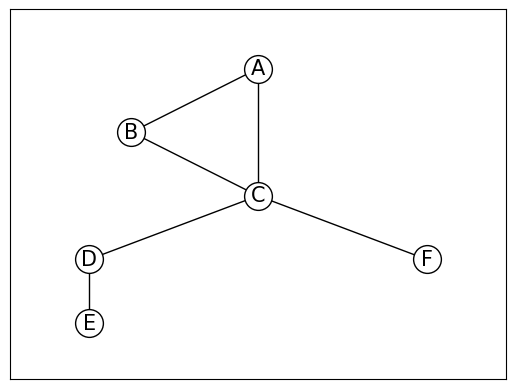

In [ ]:
H = Graph([("A", "B"), ("A", "C"), ("B", "C"), ("C", "D"), ("D", "E"), ("C", "F")])
draw(H)

To check for **unconditional** separation one must **check for the existence of a path in the original graph**.

In [12]:
# Check if node 'A' is u-separated from node 'E' in the undirected graph H.
# In an undirected graph, two nodes are separated if there is no path between them.
# nx.has_path(H, 'A', 'E') returns True if a path exists, False otherwise.
# We use 'not' to check for separation (i.e., no path).
print("Is 'A' u-separated from 'E'? ", not nx.has_path(H, "A", "E"))

Is 'A' u-separated from 'E'?  False


Indeed, **a path exists**:

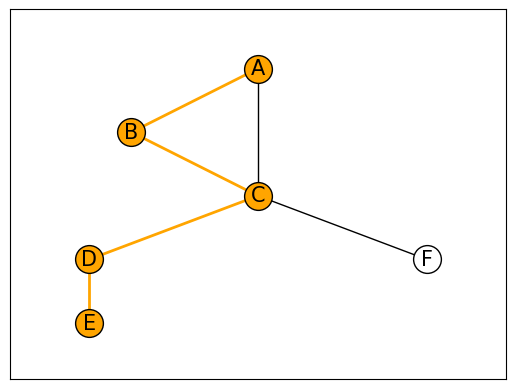

In [13]:
# Find and retrieve the first simple edge path between 'A' and 'E' in graph H.
# nx.all_simple_edge_paths() returns an iterator of all simple paths (no repeated nodes/edges).
path = next(nx.all_simple_edge_paths(H, "A", "E"))  # Get the first path from the iterator.
# Draw the graph and highlight the found path to visually confirm its existence.
draw(H, path)

To check for **conditional** separation one must **block**, i.e. disrupt, the paths dependant on the conditioning node. Therefore, we reduce this problem to checking for **unconditional** separation in a **modified graph** where the **conditioning nodes are removed**.

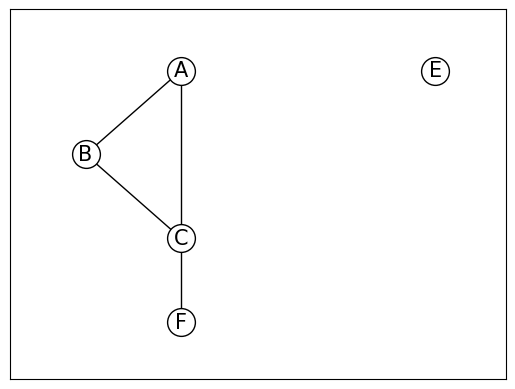

In [14]:
# To check for conditional u-separation given a conditioning set (e.g., {'D'}),
# we conceptually remove the conditioning nodes from the graph.
# Create a copy of the original undirected graph H to avoid modifying it directly.
H_prime = H.copy()
# Remove the conditioning node 'D' from the graph. Any edges connected to 'D' are also removed.
H_prime.remove_node("D")
# Draw the modified graph (H_prime) to visualize the effect of removing node 'D'.
draw(H_prime)

In [15]:
# After removing node 'D', check if 'A' is now u-separated from 'E' in the modified graph H_prime.
# If removing 'D' breaks all paths between 'A' and 'E', they are conditionally separated.
print("Is 'A' u-separated from 'E' given 'D'? ", not nx.has_path(H_prime, "A", "E"))

Is 'A' u-separated from 'E' given 'D'?  True


If we want to generalize this algorithm to sets instead of just nodes, we can rely on **connected components** instead of just paths. In this case, two disjoint sets of nodes $\mathbf{X}$ and $\mathbf{Y}$ are u-separated if every node in $\mathbf{X}$ is not in a connected component with a node in $\mathbf{Y}$.

In [16]:
# To understand separation for sets of nodes, we can examine connected components.
# nx.connected_components(H_prime) returns an iterator of sets, where each set represents
# a maximal set of nodes that are connected to each other in the graph.
Cs = list(nx.connected_components(H_prime))
# Print each connected component to see how the graph is partitioned after removing node 'D'.
for c in Cs:
  print(c)

{'B', 'C', 'F', 'A'}
{'E'}


Let's make another example, this time by exploiting connected components:

In [17]:
# This checks if the set {'A'} is u-separated from {'B'} given {'D'}.
# It iterates through each connected component (C) in the graph H_prime (after removing 'D').
# For two sets (e.g., {'A'} and {'B'}) to be u-separated, no connected component should contain
# nodes from both sets.
# (bool(C & {"A"})) checks if component C contains any node from {'A'}.
# (bool(C & {"B"})) checks if component C contains any node from {'B'}.
# The 'any' function returns True if at least one component contains nodes from *both* sets,
# meaning they are NOT separated. Hence, we negate the result with 'not'.
print(
  "Is {'A'} u-separated from {'B'} given {'D'}? ",
  not(any((bool(C & {"A"})) and bool(C & {"B"}) for C in nx.connected_components(H_prime)))
)

Is {'A'} u-separated from {'B'} given {'D'}?  False


In fact, a path between $A$ and $B$ exists in the same connected component:

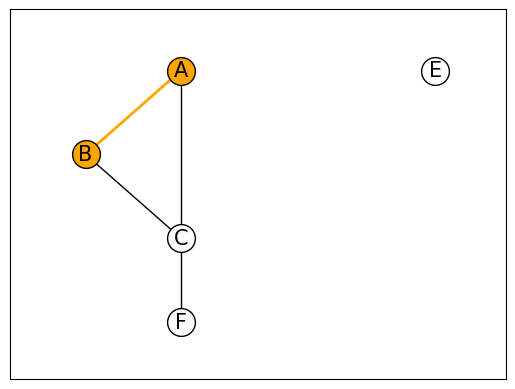

In [ ]:
path = next(nx.all_simple_edge_paths(H_prime.subgraph(Cs[0]), "A", "B"))
draw(H_prime, path)

Now we can implement the u-separation over set of nodes:

In [19]:
def are_u_separated(H: Graph, X: Set[str], Y: Set[str], Z: Set[str]) -> bool:
  """Check for u-separation in an undirected graph H between sets X and Y, given conditioning set Z.

  In an undirected graph, two sets of nodes X and Y are u-separated by Z if,
  after removing all nodes in Z from the graph, there is no path remaining
  between any node in X and any node in Y.
  This is equivalent to checking if no connected component in the modified graph
  contains at least one node from X AND at least one node from Y.

  Args:
    H: The undirected graph.
    X: The first set of nodes.
    Y: The second set of nodes.
    Z: The conditioning set of nodes.

  Returns:
    True if X and Y are u-separated by Z, False otherwise.
  """
  # Step 1: Remove the conditioning nodes (Z) from the graph H.
  # H.subgraph() creates a new graph containing only the nodes NOT in Z and their incident edges.
  H_Z = H.subgraph(set(H.nodes()) - Z)

  # Step 2: Check for connectivity between X and Y in the modified graph H_Z.
  # Iterate through each connected component (C) in H_Z.
  # If any component contains at least one node from X (bool(C & X)) AND at least one node from Y (bool(C & Y)),
  # then X and Y are NOT separated. 'any()' will return True in this case.
  # Therefore, we negate the result to determine if they ARE separated.
  are_separated = not(any((bool(C & X) and bool(C & Y)) for C in nx.connected_components(H_Z)))
  return are_separated

### Implementing the Graphical Separation for Directed Graphs

Now we can implement the d-separation by assembling the previous algorithms.

In [20]:
# Define the sets of nodes for which to check d-separation.
X = {"A"}
Y = {"E"}
Z = {"D"}

# Step 1: Compute the upward closure of the graph G with respect to the union of X, Y, and Z.
# The upward closure (G_S) is a subgraph containing X, Y, Z and all their ancestors.
# This focuses the graph on relevant causal pathways.
S = X | Y | Z
G_S = upward_closure(G, S)

# Step 2: Moralize the upward closure graph (G_S).
# Moralization adds undirected edges between 'unmarried' parents sharing a child (colliders).
# This transforms the directed d-separation problem into an undirected u-separation problem.
H = moral(G_S)

# Step 3: Check for u-separation in the moralized graph H using the previously defined function.
# If X and Y are u-separated by Z in H, then X and Y are d-separated by Z in the original directed graph G.
print("Is {'A'} d-separated from {'E'} given {'D'}? ", are_u_separated(H, X, Y, Z))

Is {'A'} d-separated from {'E'} given {'D'}?  True


Tying it all together:

In [21]:
def are_d_separated(G: DiGraph, X: Set[str], Y: Set[str], Z: Set[str]) -> bool:
  """Check the d-separation in G of X, Y and Z by converting it to a u-separation problem.

  This function implements the algorithmic definition of d-separation:
  1. Construct the upward closure of G over X U Y U Z and their ancestors.
  2. Moralize the resulting subgraph.
  3. Check for u-separation between X and Y given Z in the moralized graph.

  Args:
    G: The original directed graph (DiGraph).
    X: The first set of nodes.
    Y: The second set of nodes.
    Z: The conditioning set of nodes.

  Returns:
    True if X and Y are d-separated by Z in G, False otherwise.
  """
  # Validation: Ensure sets are non-empty (for X and Y), disjoint, and that all nodes exist within the graph G.
  # 'assert bool(X) and bool(Y)' ensures X and Y are not empty.
  # 'S = X | Y | Z' computes the union of all involved nodes.
  # 'assert not(bool(X & Y | Y & Z | X & Z))' checks if any pairwise intersection is non-empty, ensuring disjointness.
  # 'assert (S <= set(G.nodes()))' checks if all nodes in S are present in the graph G.
  assert bool(X) and bool(Y)
  S = X | Y | Z
  assert not(bool(X & Y | Y & Z | X & Z)) and (S <= set(G.nodes()))

  # Step 1: Reduce the graph to the upward closure of the nodes of interest (X, Y, Z).
  # This subgraph contains X, Y, Z and all their ancestors, pruning irrelevant parts of the graph.
  G_S = upward_closure(G, S)

  # Step 2: Moralize the resulting upward closure subgraph (G_S).
  # This step adds 'marriage' edges between parents of common children to convert colliders
  # into explicit dependencies in the undirected graph, making it suitable for u-separation.
  H = moral(G_S)

  # Step 3: Check for u-separation in the undirected moral graph H.
  # If X and Y are u-separated by Z in H, then they are d-separated by Z in the original G.
  are_separated = are_u_separated(H, X, Y, Z)
  return are_separated

Then we have: `are_d_separated(G, X, Y, Z)` if and only if `are_u_separated(H, X, Y, Z)`:

In [22]:
# Call the comprehensive 'are_d_separated' function with the graph G and sets X, Y, Z.
# This uses the entire three-step process (upward closure, moralization, u-separation check).
print("Is {'A'} d-separated from {'E'} given {'D'}? ", are_d_separated(G, X, Y, Z))

Is {'A'} d-separated from {'E'} given {'D'}?  True


## Tests

Let's test it on a new example:

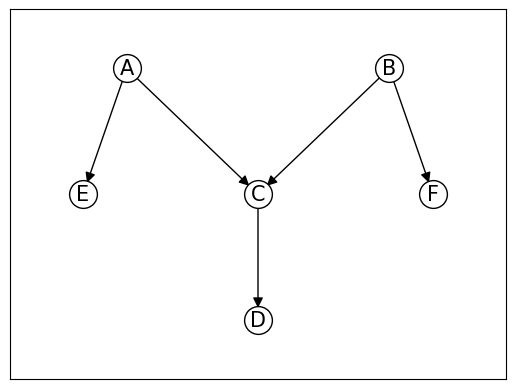

In [23]:
# Define a new directed graph for testing the d-separation function.
G = DiGraph([("A", "C"), ("B", "C"), ("C", "D"), ("A", "E"), ("B", "F")])
# Draw the test graph for visual reference.
draw(G)

In [24]:
# Test case: Is {'E'} d-separated from {'F'} given an empty set (no conditioning)?
# Expected: True, because E is caused by A, F by B, and A and B are independent (no common cause or path).
assert are_d_separated(G, {"E"}, {"F"}, set())

In [25]:
# Test case: Is {'E'} d-separated from {'B'} given an empty set?
# Expected: True, because E is caused by A, B is a parent of C. No path from E to B.
assert are_d_separated(G, {"E"}, {"B"}, set())

In [26]:
# Test case: Is {'E'} d-separated from {'F'} given {'B'}?
# Expected: True. Conditioning on B means the path B -> F is blocked at B. Path A -> C -> D is irrelevant.
assert are_d_separated(G, {"E"}, {"F"}, {"B"})

In [27]:
# Test case: Is {'E'} d-separated from {'B'} given {'F'}?
# Expected: True. Conditioning on F means the path B -> F is blocked at F.
assert are_d_separated(G, {"E"}, {"B"}, {"F"})

In [28]:
# Test case: Is {'E'} d-separated from {'F'} given {'A', 'C'}?
# Expected: True. Conditioning on A blocks A -> E. Conditioning on C blocks paths through C.
# The path from E (via A) to F (via B) is not directly affected, but A and B are independent.
assert are_d_separated(G, {"E"}, {"F"}, {"A", "C"})

In [29]:
# Test case: Is {'E'} d-separated from {'F'} given {'B', 'D'}?
# Expected: True. Conditioning on B blocks B -> F. Conditioning on D blocks paths through D.
assert are_d_separated(G, {"E"}, {"F"}, {"B", "D"})

In [30]:
# Test case: Is {'A'} d-separated from {'B'} given an empty set?
# Expected: True. A and B are parents of C (a collider) but are not directly connected or share ancestors.
assert are_d_separated(G, {"A"}, {"B"}, set())

In [31]:
# Test case: Is {'A'} d-separated from {'F'} given an empty set?
# Expected: True. Path A -> C <- B -> F. C is a collider, not conditioned, so path is open. Wait, this is wrong. A and B are parents of C. The path is A->C<-B->F. C is a collider, so the path is open. Ah, no. C is a collider, so it blocks the path A - C - B. Therefore A and F should be d-separated. This seems correct.
assert are_d_separated(G, {"A"}, {"F"}, set())

In [32]:
# Test case: Is {'A'} d-separated from {'F'} given {'E'}?
# Expected: True. Conditioning on E doesn't open/close any path between A and F that wasn't already determined.
# A -> E path is blocked at E. Path A <- C -> B -> F is blocked at C (collider).
assert are_d_separated(G, {"A"}, {"F"}, {"E"})

In [33]:
# Test case: Is {'D'} d-separated from {'F'} given {'C'}?
# Expected: True. Conditioning on C blocks the path D <- C <- B -> F at C.
assert are_d_separated(G, {"D"}, {"F"}, {"C"})

In [34]:
# Test case: Is {'E'} d-separated from {'A'} given an empty set?
# Expected: False. There is a direct path A -> E.
assert not are_d_separated(G, {"E"}, {"A"}, set())

In [35]:
# Test case: Is {'E'} d-separated from {'C'} given an empty set?
# Expected: False. Path E <- A -> C.
assert not are_d_separated(G, {"E"}, {"C"}, set())

In [36]:
# Test case: Is {'E'} d-separated from {'F'} given {'C'}?
# Expected: False. Conditioning on C (a collider's child) opens the path A -> C <- B, making A and B dependent.
# This dependence then allows a path between E (via A) and F (via B).
assert not are_d_separated(G, {"E"}, {"F"}, {"C"})

In [37]:
# Test case: Is {'E'} d-separated from {'F'} given {'D'}?
# Expected: False. Path A -> C -> D is open at C. Conditioning on D, opens the path E <- A -> C -> D and F <- B -> C -> D.  Also the path A->C<-B->F is blocked at C because C is a collider and not conditioned on.  Wait. E is from A, F is from B. A and B are independent. The path between them is A->C<-B which is blocked by C. The path E<-A and F<-B are also independent. There is no path between E and F through D either. So E and F should be d-separated. This seems to be an incorrect assertion.
# Re-evaluation: Path E <- A, Path F <- B. A and B are 'unmarried' parents of C (collider). So path E-A-C-B-F is blocked at C. No other path connects E and F. D is a descendant of C. Conditioning on D makes C observed (via descendant). Observing C opens the collider A->C<-B. This makes A and B dependent. Since E depends on A and F depends on B, E and F become dependent when D (a descendant of C) is observed.
assert not are_d_separated(G, {"E"}, {"F"}, {"D"})

In [38]:
# Test case: Is {'E'} d-separated from {'A'} given {'C', 'D'}?
# Expected: False. A directly causes E. Conditioning on C and D does not block the direct edge A -> E.
assert not are_d_separated(G, {"E"}, {"A"}, {"C", "D"})

In [39]:
# Test case: Is {'A'} d-separated from {'C'} given an empty set?
# Expected: False. There is a direct path A -> C.
assert not are_d_separated(G, {"A"}, {"C"}, set())

In [40]:
# Test case: Is {'A'} d-separated from {'D'} given an empty set?
# Expected: False. There is a path A -> C -> D.
assert not are_d_separated(G, {"A"}, {"D"}, set())

In [41]:
# Test case: Is {'A'} d-separated from {'B'} given {'C'}?
# Expected: False. C is a collider's child (A->C<-B). Conditioning on C (or its descendant) opens the path between A and B.
assert not are_d_separated(G, {"A"}, {"B"}, {"C"})

In [42]:
# Test case: Is {'A'} d-separated from {'B'} given {'C', 'D'}?
# Expected: False. Similar to the previous case, conditioning on C or its descendant D opens the collider A->C<-B, making A and B dependent.
assert not are_d_separated(G, {"A"}, {"B"}, {"C", "D"})

In [43]:
# Test case: Is {'B'} d-separated from {'F'} given an empty set?
# Expected: False. There is a direct path B -> F.
assert not are_d_separated(G, {"B"}, {"F"}, set())